# Prediksi Produksi Beras Menggunakan Graph Neural Network (GNN)

Notebook ini memanfaatkan Graph Neural Network (GNN) untuk memprediksi produksi beras di Indonesia berdasarkan data historis dari FAOSTAT. Setiap node pada graf merepresentasikan produksi beras pada satu tahun, dan edge menghubungkan tahun-tahun secara berurutan.

## Alur Kerja:
1. **Persiapan Data**  
    Data produksi beras difilter dan diambil kolom tahun serta nilai produksinya.

2. **Representasi Graf**  
    - Node: Nilai produksi tiap tahun.
    - Edge: Hubungan antar tahun secara berurutan (misal, 1961 terhubung ke 1962, dst).

3. **Pembangunan Model GNN**  
    Model GNN (Graph Neural Network) digunakan untuk mempelajari pola dari data historis.

4. **Pelatihan dan Evaluasi**  
    Model dilatih untuk merekonstruksi data historis, lalu dilakukan prediksi dan evaluasi menggunakan RMSE.

5. **Forecasting**  
    Model digunakan untuk memproyeksikan produksi beras beberapa tahun ke depan, baik dengan rata-rata historis maupun inisialisasi berbasis exponential smoothing.

6. **Visualisasi**  
    Hasil prediksi dan forecast divisualisasikan bersama data aktual, serta ditampilkan interval kepercayaan menggunakan Monte Carlo Dropout.

## Variabel Utama:
- `rice_production`: DataFrame berisi tahun dan produksi beras.
- `node_features`: Fitur node untuk graf (produksi per tahun).
- `edge_index`: Koneksi antar node (tahun).
- `model`: Model GNN yang digunakan.
- `predictions`: Hasil prediksi model pada data historis.
- `forecast_values`: Hasil prediksi untuk tahun-tahun mendatang.
- `years`, `forecast_years`: Tahun historis dan tahun prediksi.

Notebook ini dapat dikembangkan untuk prediksi komoditas lain atau diterapkan pada data dengan struktur waktu serupa.

## 1. Persiapan Data

In [2]:
import pandas as pd

dataset = pd.read_csv('FAOSTAT_data_en_5-14-2025.csv')
dataset.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,360,Indonesia,5312,Area harvested,01929.07,"Abaca, manila hemp, raw",1961,1961,ha,600.0,E,Estimated value,NaN
1,QCL,Crops and livestock products,360,Indonesia,5412,Yield,01929.07,"Abaca, manila hemp, raw",1961,1961,kg/ha,666.7,E,Estimated value,NaN
2,QCL,Crops and livestock products,360,Indonesia,5510,Production,01929.07,"Abaca, manila hemp, raw",1961,1961,t,400.0,A,Official figure,NaN
3,QCL,Crops and livestock products,360,Indonesia,5312,Area harvested,01929.07,"Abaca, manila hemp, raw",1962,1962,ha,600.0,E,Estimated value,NaN
4,QCL,Crops and livestock products,360,Indonesia,5412,Yield,01929.07,"Abaca, manila hemp, raw",1962,1962,kg/ha,666.7,E,Estimated value,NaN


In [3]:
dataset = dataset[dataset['Item'] == 'Rice']
dataset

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
13181,QCL,Crops and livestock products,360,Indonesia,5312,Area harvested,0113,Rice,1961,1961,ha,6857000.00,A,Official figure,NaN
13182,QCL,Crops and livestock products,360,Indonesia,5412,Yield,0113,Rice,1961,1961,kg/ha,1762.30,A,Official figure,NaN
13183,QCL,Crops and livestock products,360,Indonesia,5510,Production,0113,Rice,1961,1961,t,12084000.00,A,Official figure,NaN
13184,QCL,Crops and livestock products,360,Indonesia,5312,Area harvested,0113,Rice,1962,1962,ha,7283000.00,A,Official figure,NaN
13185,QCL,Crops and livestock products,360,Indonesia,5412,Yield,0113,Rice,1962,1962,kg/ha,1785.50,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13365,QCL,Crops and livestock products,360,Indonesia,5412,Yield,0113,Rice,2022,2022,kg/ha,5237.80,A,Official figure,NaN
13366,QCL,Crops and livestock products,360,Indonesia,5510,Production,0113,Rice,2022,2022,t,54748977.08,A,Official figure,NaN
13367,QCL,Crops and livestock products,360,Indonesia,5312,Area harvested,0113,Rice,2023,2023,ha,10213705.00,A,Official figure,NaN
13368,QCL,Crops and livestock products,360,Indonesia,5412,Yield,0113,Rice,2023,2023,kg/ha,5285.20,A,Official figure,NaN


In [4]:
# Filter data untuk masing-masing elemen
area_harvested_df = dataset[dataset['Element'] == 'Area harvested'][['Year', 'Value']].reset_index(drop=True)
yield_df = dataset[dataset['Element'] == 'Yield'][['Year', 'Value']].reset_index(drop=True)
production_df = dataset[dataset['Element'] == 'Production'][['Year', 'Value']].reset_index(drop=True)

# Tampilkan contoh
print("Area Harvested:")
print(area_harvested_df.head())
print("\nYield:")
print(yield_df.head())
print("\nProduction:")
print(production_df.head())

Area Harvested:
   Year      Value
0  1961  6857000.0
1  1962  7283000.0
2  1963  6731000.0
3  1964  6980000.0
4  1965  7327000.0

Yield:
   Year   Value
0  1961  1762.3
1  1962  1785.5
2  1963  1722.6
3  1964  1763.0
4  1965  1770.8

Production:
   Year       Value
0  1961  12084000.0
1  1962  13004000.0
2  1963  11595000.0
3  1964  12306000.0
4  1965  12975000.0


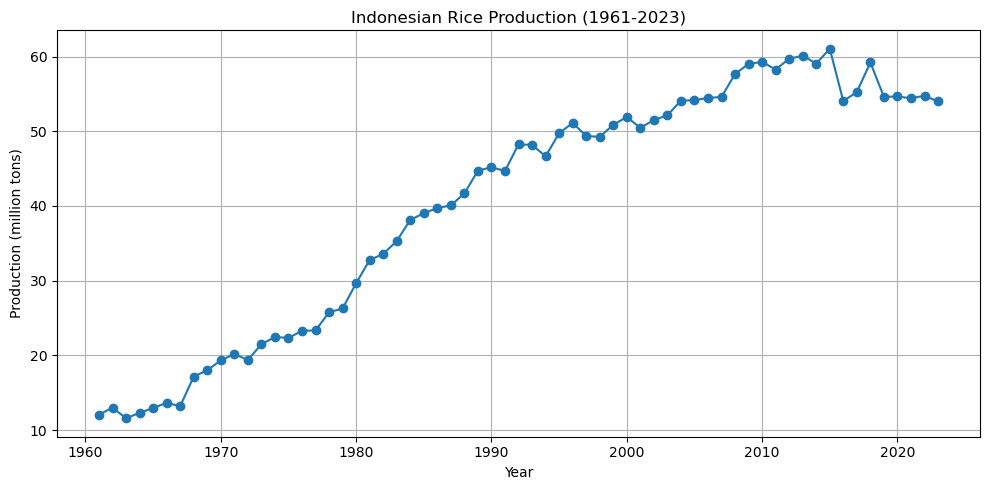

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(production_df['Year'], production_df['Value'] / 1e6, marker='o', linestyle='-')
plt.title('Indonesian Rice Production (1961-2023)')
plt.xlabel('Year')
plt.ylabel('Production (million tons)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
import torch
from torch_geometric.data import Data

# Ambil fitur node dari produksi beras per tahun
node_features = torch.tensor(production_df['Value'].dropna().values, dtype=torch.float).view(-1, 1)

# Buat edge_index: menghubungkan tahun-tahun secara berurutan (graf linier)
num_nodes = node_features.size(0)
edge_index = torch.tensor(
    [[i, i + 1] for i in range(num_nodes - 1)] + [[i + 1, i] for i in range(num_nodes - 1)],
    dtype=torch.long
).t()

# (Opsional) Label dummy jika diperlukan
labels = torch.zeros(num_nodes, dtype=torch.long)

# Buat objek graf PyTorch Geometric
data = Data(x=node_features, edge_index=edge_index, y=labels)

print(data)

Data(x=[63, 1], edge_index=[2, 124], y=[63])


In [7]:
from torch_geometric.nn import GCNConv

import torch.nn as nn
import torch.nn.functional as F

class GNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# Contoh inisialisasi model
model = GNN(input_dim=1, hidden_dim=16, output_dim=1)
print(model)

GNN(
  (conv1): GCNConv(1, 16)
  (conv2): GCNConv(16, 1)
)


In [8]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Melatih model GNN untuk merekonstruksi data historis produksi beras
num_epochs = 200
model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    out = model(data)
    # Target adalah produksi aktual (node_features)
    loss = loss_fn(out, node_features)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.2f}")

# Simpan output terakhir untuk evaluasi/prediksi
predictions = out.detach().cpu().numpy()

Epoch 1/200, Loss: 4017215519064064.00
Epoch 20/200, Loss: 184904700657664.00
Epoch 40/200, Loss: 56859524333568.00
Epoch 60/200, Loss: 3727580987392.00
Epoch 80/200, Loss: 1555519111168.00
Epoch 100/200, Loss: 1579902042112.00
Epoch 120/200, Loss: 1550334296064.00
Epoch 140/200, Loss: 1541868355584.00
Epoch 160/200, Loss: 1540490657792.00
Epoch 180/200, Loss: 1540306108416.00
Epoch 200/200, Loss: 1540283695104.00


In [9]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Hitung RMSE antara prediksi model dan data aktual
rmse = np.sqrt(mean_squared_error(production_df['Value'].values, predictions.flatten()))
print(f"RMSE: {rmse:.2f}")

RMSE: 1241081.63


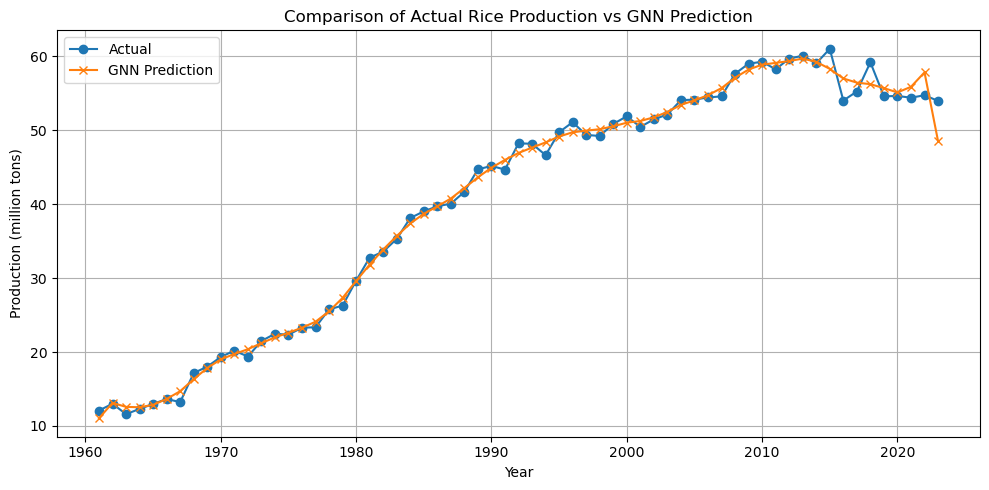

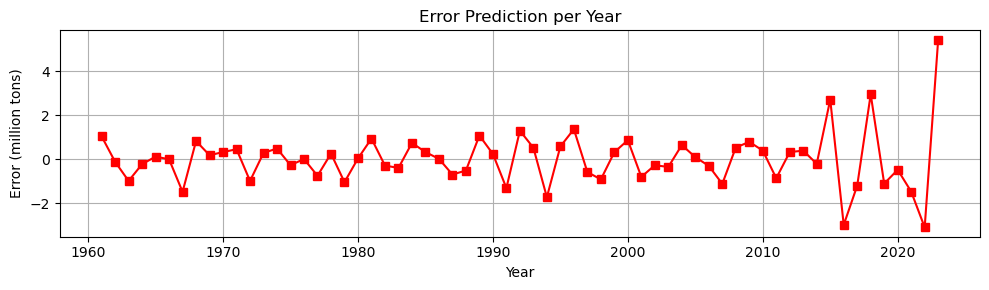

RMSE: 1.24 million tons
Mean absolute error: 0.84 million tons


In [10]:
years = production_df['Year'].values

plt.figure(figsize=(10, 5))
plt.plot(years, production_df['Value'] / 1e6, label='Actual', marker='o')
plt.plot(years, predictions.flatten() / 1e6, label='GNN Prediction', marker='x')
plt.title('Comparison of Actual Rice Production vs GNN Prediction')
plt.xlabel('Year')
plt.ylabel('Production (million tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate error
error = production_df['Value'].values - predictions.flatten()

# Error plot
error_million = error / 1e6
plt.figure(figsize=(10, 3))
plt.plot(years, error_million, marker='s', color='red')
plt.title('Error Prediction per Year')
plt.xlabel('Year')
plt.ylabel('Error (million tons)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"RMSE: {rmse/1e6:.2f} million tons")
print(f"Mean absolute error: {np.mean(np.abs(error))/1e6:.2f} million tons")

In [11]:
from torch_geometric.nn import GCNConv

import torch.nn as nn
import torch.nn.functional as F

class GNNDropout(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(GNNDropout, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Inisialisasi model baru dengan dropout
model = GNNDropout(input_dim=1, hidden_dim=16, output_dim=1, dropout=0.3)
print(model)

GNNDropout(
  (conv1): GCNConv(1, 16)
  (conv2): GCNConv(16, 1)
)


In [12]:
# Split ulang data: train sebelum split_year, test setelah/sama split_year
split_year = 2011
train_mask = years < split_year
test_mask = ~train_mask

train_idx = np.where(train_mask)[0]
test_idx = np.where(test_mask)[0]

# Siapkan data dan target untuk train/test
x_train = node_features[train_idx]
x_test = node_features[test_idx]

# Buat ulang model (reset bobot)
model = GNNDropout(input_dim=1, hidden_dim=16, output_dim=1, dropout=0.3)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Training hanya pada data train
num_epochs = 200
model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    # Forward hanya pada node train
    out = model(data)
    loss = loss_fn(out[train_idx], x_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.2f}")

# Evaluasi: prediksi seluruh node, hitung RMSE train dan test
model.eval()
with torch.no_grad():
    out = model(data)
    predictions = out.detach().cpu().numpy()
    train_pred = predictions[train_idx].flatten()
    test_pred = predictions[test_idx].flatten()
    train_actual = x_train.cpu().numpy().flatten()
    test_actual = x_test.cpu().numpy().flatten()
    rmse_train = np.sqrt(mean_squared_error(train_actual, train_pred))
    rmse_test = np.sqrt(mean_squared_error(test_actual, test_pred))

print(f"RMSE Train: {rmse_train:.2f}")
print(f"RMSE Test: {rmse_test:.2f}")

Epoch 1/200, Loss: 2532749999079424.00
Epoch 20/200, Loss: 429869049577472.00
Epoch 40/200, Loss: 137518787854336.00
Epoch 60/200, Loss: 98649082167296.00
Epoch 80/200, Loss: 81097161441280.00
Epoch 100/200, Loss: 85204785954816.00
Epoch 120/200, Loss: 129144994136064.00
Epoch 140/200, Loss: 51794327633920.00
Epoch 160/200, Loss: 82872476106752.00
Epoch 180/200, Loss: 74329131843584.00
Epoch 200/200, Loss: 73764217815040.00
RMSE Train: 1883912.25
RMSE Test: 3392180.75


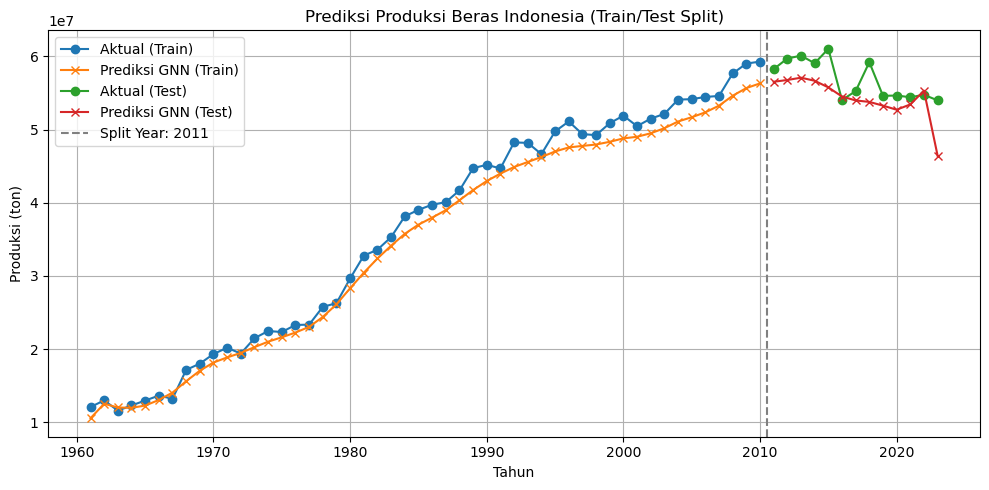

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(years[train_idx], train_actual, label='Aktual (Train)', marker='o')
plt.plot(years[train_idx], train_pred, label='Prediksi GNN (Train)', marker='x')
plt.plot(years[test_idx], test_actual, label='Aktual (Test)', marker='o', color='tab:green')
plt.plot(years[test_idx], test_pred, label='Prediksi GNN (Test)', marker='x', color='tab:red')
plt.axvline(split_year - 0.5, color='gray', linestyle='--', label=f'Split Year: {split_year}')
plt.title('Prediksi Produksi Beras Indonesia (Train/Test Split)')
plt.xlabel('Tahun')
plt.ylabel('Produksi (ton)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

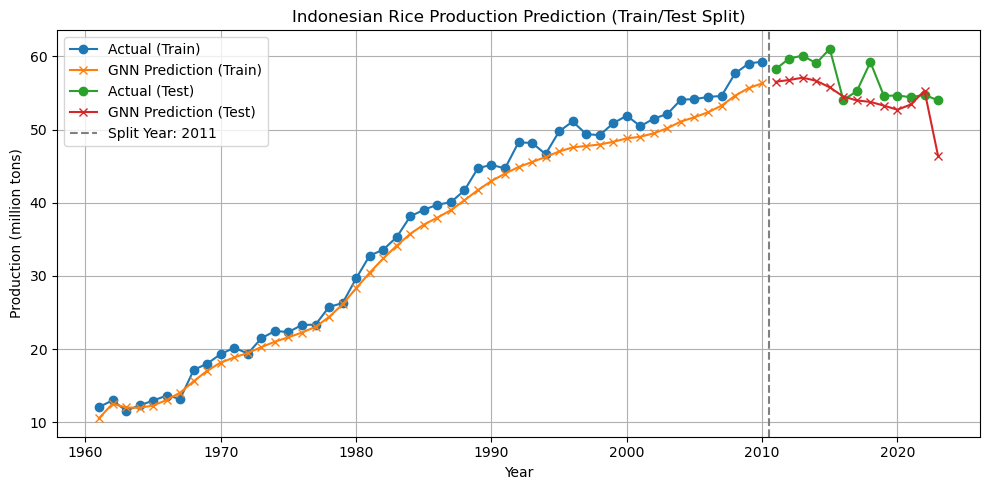

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(years[train_idx], train_actual / 1e6, label='Actual (Train)', marker='o')
plt.plot(years[train_idx], train_pred / 1e6, label='GNN Prediction (Train)', marker='x')
plt.plot(years[test_idx], test_actual / 1e6, label='Actual (Test)', marker='o', color='tab:green')
plt.plot(years[test_idx], test_pred / 1e6, label='GNN Prediction (Test)', marker='x', color='tab:red')
plt.axvline(split_year - 0.5, color='gray', linestyle='--', label=f'Split Year: {split_year}')
plt.title('Indonesian Rice Production Prediction (Train/Test Split)')
plt.xlabel('Year')
plt.ylabel('Production (million tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

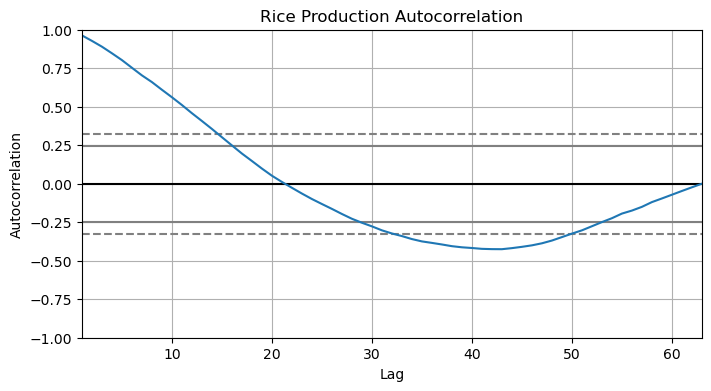

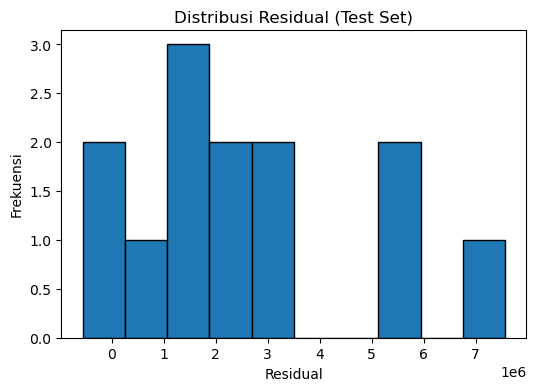

Shapiro-Wilk p-value: 0.3072 (p>0.05: residual normal)


In [15]:
from pandas.plotting import autocorrelation_plot

# Beberapa analisis tambahan yang dapat dilakukan:
# 1. Analisis Autokorelasi: Untuk melihat pola musiman atau tren jangka panjang.

plt.figure(figsize=(8, 4))
autocorrelation_plot(production_df['Value'])
plt.title('Rice Production Autocorrelation')
plt.show()

# 2. Analisis Residual: Uji normalitas dan heteroskedastisitas error prediksi.
import scipy.stats as stats

residuals = test_actual - test_pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=10, edgecolor='k')
plt.title('Distribusi Residual (Test Set)')
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.show()

# Uji normalitas residual (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f} (p>0.05: residual normal)")

# 3. Feature Importance: Jika ada fitur tambahan, bisa gunakan SHAP atau analisis sensitivitas.
# 4. Analisis Robustness: Uji model pada data dengan noise atau data tahun ekstrem.
# 5. Perbandingan dengan Model Lain: Misal ARIMA, LSTM, atau regresi linier sederhana.

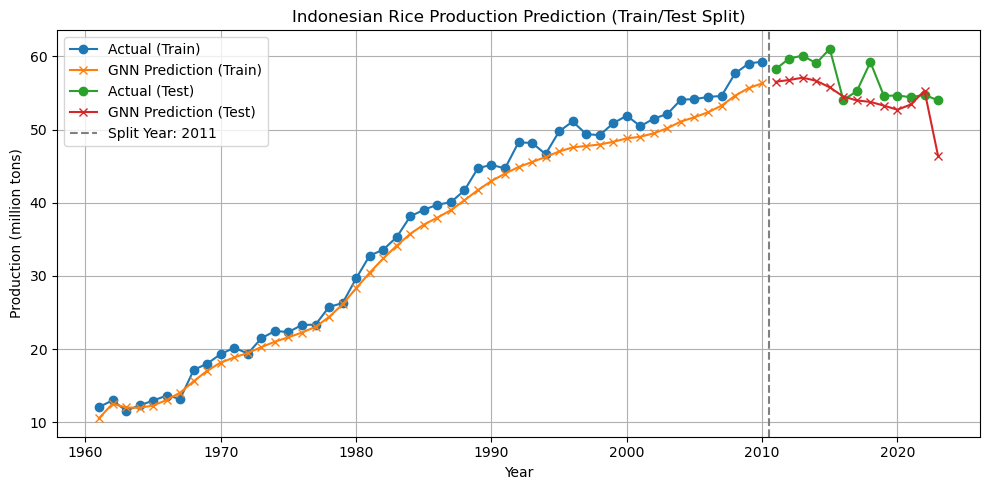

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(years[train_idx], train_actual / 1e6, label='Actual (Train)', marker='o')
plt.plot(years[train_idx], train_pred / 1e6, label='GNN Prediction (Train)', marker='x')
plt.plot(years[test_idx], test_actual / 1e6, label='Actual (Test)', marker='o', color='tab:green')
plt.plot(years[test_idx], test_pred / 1e6, label='GNN Prediction (Test)', marker='x', color='tab:red')
plt.axvline(split_year - 0.5, color='gray', linestyle='--', label=f'Split Year: {split_year}')
plt.title('Indonesian Rice Production Prediction (Train/Test Split)')
plt.xlabel('Year')
plt.ylabel('Production (million tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE on test set with 5% noise: 4662772.14
Test year with minimum production: 2023, actual=53980992, prediction=46413616
Test year with maximum production: 2015, actual=61031000, prediction=55757040


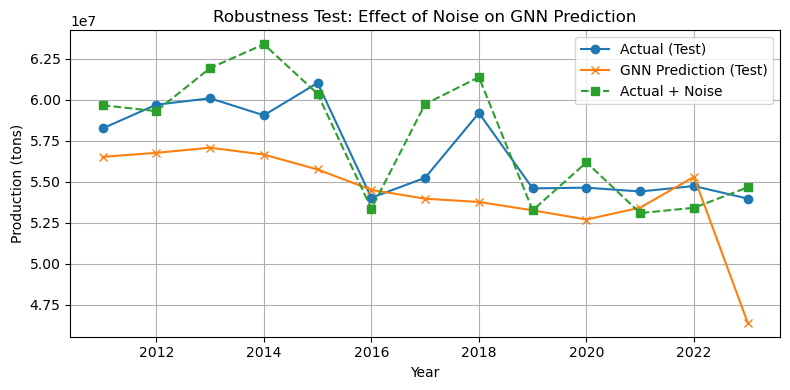

In [17]:
# Robustness Analysis: Test the model on noisy data and extreme years (in English)

# 1. Add Gaussian noise to the test data and re-evaluate RMSE
np.random.seed(42)
noise_std = 0.05 * test_actual.mean()  # 5% of the mean test production
test_actual_noisy = test_actual + np.random.normal(0, noise_std, size=test_actual.shape)

rmse_noisy = np.sqrt(mean_squared_error(test_actual_noisy, test_pred))
print(f"RMSE on test set with 5% noise: {rmse_noisy:.2f}")

# 2. Test the model on extreme years (years with minimum & maximum production in test set)
min_year_idx = np.argmin(test_actual)
max_year_idx = np.argmax(test_actual)
print(f"Test year with minimum production: {years[test_idx][min_year_idx]}, actual={test_actual[min_year_idx]:.0f}, prediction={test_pred[min_year_idx]:.0f}")
print(f"Test year with maximum production: {years[test_idx][max_year_idx]}, actual={test_actual[max_year_idx]:.0f}, prediction={test_pred[max_year_idx]:.0f}")

# Visualize predictions vs actual with noise
plt.figure(figsize=(8, 4))
plt.plot(years[test_idx], test_actual, label='Actual (Test)', marker='o')
plt.plot(years[test_idx], test_pred, label='GNN Prediction (Test)', marker='x')
plt.plot(years[test_idx], test_actual_noisy, label='Actual + Noise', marker='s', linestyle='--')
plt.title('Robustness Test: Effect of Noise on GNN Prediction')
plt.xlabel('Year')
plt.ylabel('Production (tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

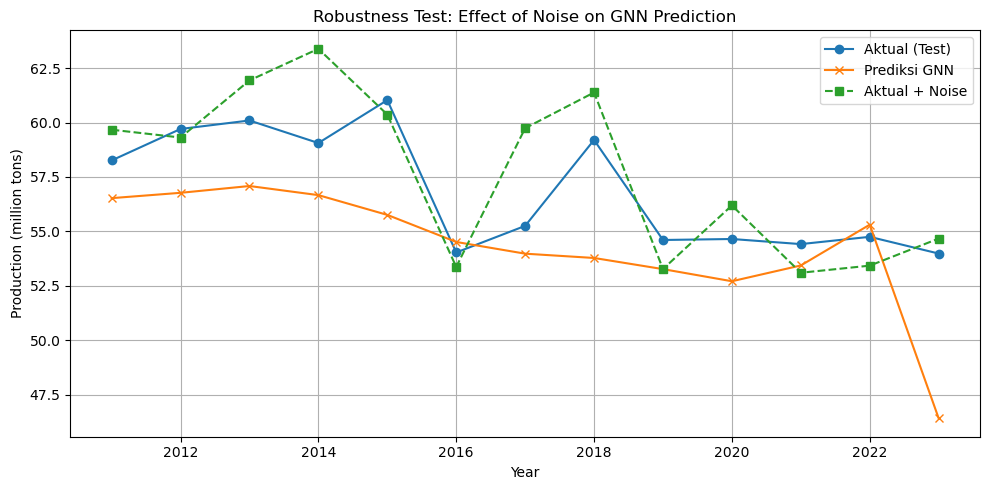

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(years[test_idx], test_actual / 1e6, label='Aktual (Test)', marker='o')
plt.plot(years[test_idx], test_pred / 1e6, label='Prediksi GNN', marker='x')
plt.plot(years[test_idx], test_actual_noisy / 1e6, label='Aktual + Noise', marker='s', linestyle='--')
plt.title('Robustness Test: Effect of Noise on GNN Prediction')
plt.xlabel('Year')
plt.ylabel('Production (million tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA

# Siapkan data untuk model linier sederhana
X_years = years.reshape(-1, 1)
y_prod = production_df['Value'].values

# Linear Regression
linreg = LinearRegression()
linreg.fit(X_years[train_idx], y_prod[train_idx])
linreg_pred = linreg.predict(X_years[test_idx])
rmse_linreg = np.sqrt(mean_squared_error(y_prod[test_idx], linreg_pred))
print(f"RMSE Linear Regression (Test): {rmse_linreg:.2f}")

# ARIMA (gunakan data train, prediksi test)
arima_order = (2, 1, 2)  # order bisa diubah sesuai hasil ACF/PACF
arima_model = ARIMA(y_prod[train_idx], order=arima_order)
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test_idx))
rmse_arima = np.sqrt(mean_squared_error(y_prod[test_idx], arima_pred))
print(f"RMSE ARIMA (Test): {rmse_arima:.2f}")

RMSE Linear Regression (Test): 14026512.49
RMSE ARIMA (Test): 10564348.00


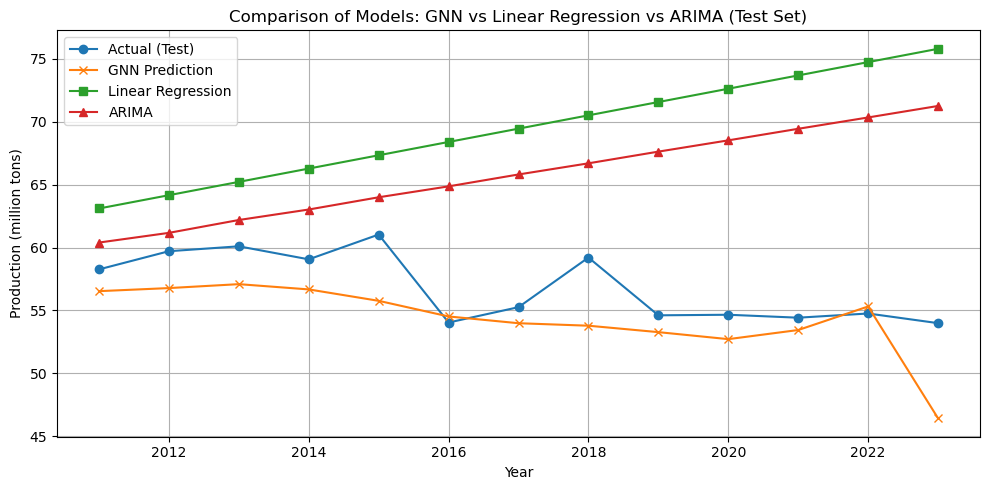

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(years[test_idx], test_actual / 1e6, label='Actual (Test)', marker='o')
plt.plot(years[test_idx], test_pred / 1e6, label='GNN Prediction', marker='x')
plt.plot(years[test_idx], linreg_pred / 1e6, label='Linear Regression', marker='s')
plt.plot(years[test_idx], arima_pred / 1e6, label='ARIMA', marker='^')
plt.title('Comparison of Models: GNN vs Linear Regression vs ARIMA (Test Set)')
plt.xlabel('Year')
plt.ylabel('Production (million tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

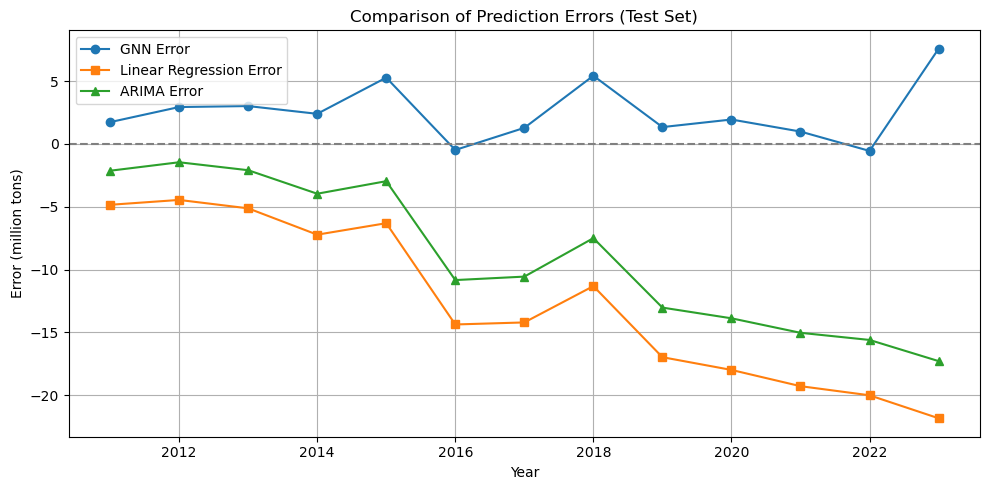

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(years[test_idx], (test_actual - test_pred) / 1e6, label='GNN Error', marker='o')
plt.plot(years[test_idx], (test_actual - linreg_pred) / 1e6, label='Linear Regression Error', marker='s')
plt.plot(years[test_idx], (test_actual - arima_pred) / 1e6, label='ARIMA Error', marker='^')
plt.title('Comparison of Prediction Errors (Test Set)')
plt.xlabel('Year')
plt.ylabel('Error (million tons)')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

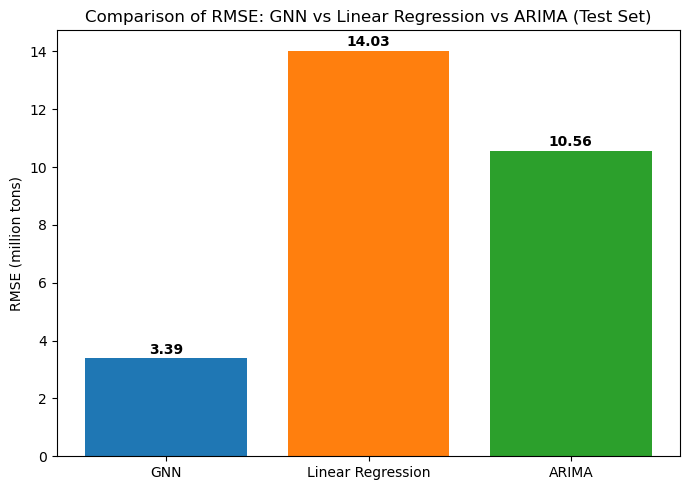

In [22]:
plt.figure(figsize=(7, 5))
model_names = ['GNN', 'Linear Regression', 'ARIMA']
rmse_values = [rmse_test, rmse_linreg, rmse_arima]
plt.bar(model_names, [v / 1e6 for v in rmse_values], color=['tab:blue', 'tab:orange', 'tab:green'])
plt.ylabel('RMSE (million tons)')
plt.title('Comparison of RMSE: GNN vs Linear Regression vs ARIMA (Test Set)')
for i, v in enumerate(rmse_values):
    plt.text(i, v / 1e6 + 0.05, f"{v/1e6:.2f}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

RMSE: 4289281.62


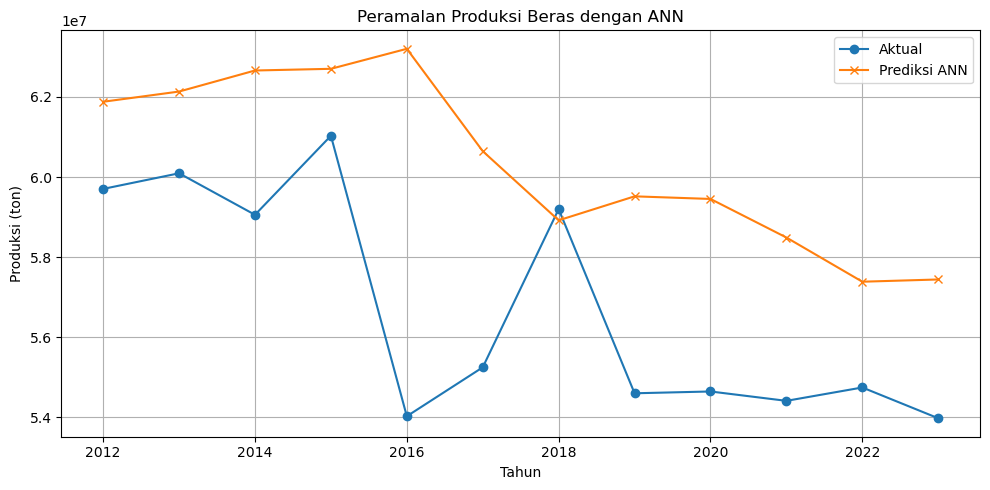

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Siapkan data: gunakan produksi tahun sebelumnya sebagai fitur
X = []
y = []
window = 3  # gunakan 3 tahun sebelumnya untuk prediksi

values = production_df['Value'].values
years = production_df['Year'].values

for i in range(window, len(values)):
    X.append(values[i-window:i])
    y.append(values[i])

X = np.array(X)
y = np.array(y)

# Split data train-test
X_train, X_test, y_train, y_test, years_train, years_test = train_test_split(
    X, y, years[window:], test_size=0.2, shuffle=False
)

# Buat dan latih model ANN
ann = MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)
ann.fit(X_train, y_train)

# Prediksi dan evaluasi
y_pred = ann.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

# Plot hasil prediksi vs aktual
plt.figure(figsize=(10,5))
plt.plot(years_test, y_test, label='Aktual', marker='o')
plt.plot(years_test, y_pred, label='Prediksi ANN', marker='x')
plt.xlabel('Tahun')
plt.ylabel('Produksi (ton)')
plt.title('Peramalan Produksi Beras dengan ANN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\Ariful\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


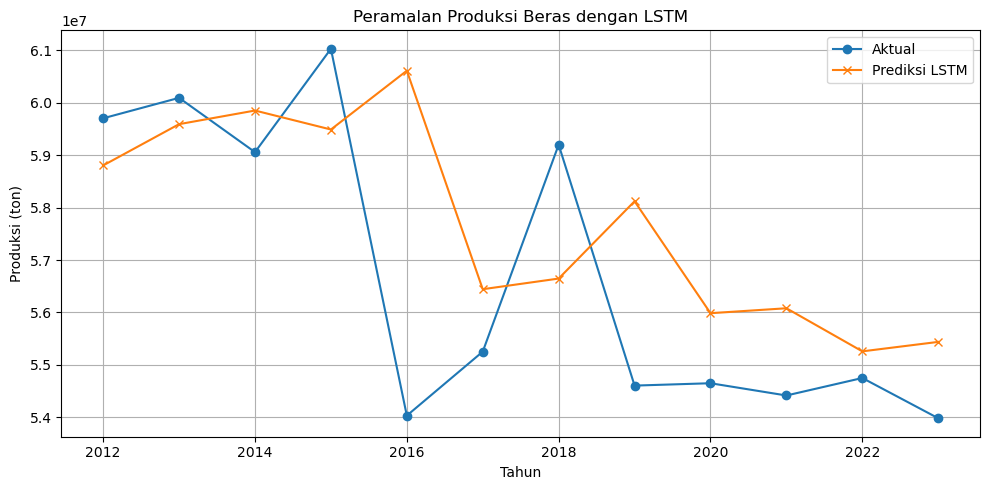

In [36]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler

# Normalisasi data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1, 1))

# Bentuk ulang X untuk RNN: (samples, timesteps, features)
X_rnn = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# Split train-test sesuai sebelumnya
split_idx = len(X_train)
X_train_rnn = X_rnn[:split_idx]
X_test_rnn = X_rnn[split_idx:]
y_train_rnn = y_scaled[:split_idx]
y_test_rnn = y_scaled[split_idx:]

# Bangun model RNN
rnn_model = Sequential([
    SimpleRNN(32, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
    Dense(16, activation='relu'),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')

# Latih model
rnn_model.fit(X_train_rnn, y_train_rnn, epochs=200, verbose=0)

# Prediksi dan inverse scaling
y_pred_rnn_scaled = rnn_model.predict(X_test_rnn)
y_pred_rnn = scaler.inverse_transform(y_pred_rnn_scaled)

# Plot hasil prediksi RNN vs aktual
plt.figure(figsize=(10,5))
plt.plot(years_test, y_test, label='Aktual', marker='o')
plt.plot(years_test, y_pred_rnn.flatten(), label='Prediksi LSTM', marker='x')
plt.xlabel('Tahun')
plt.ylabel('Produksi (ton)')
plt.title('Peramalan Produksi Beras dengan LSTM')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

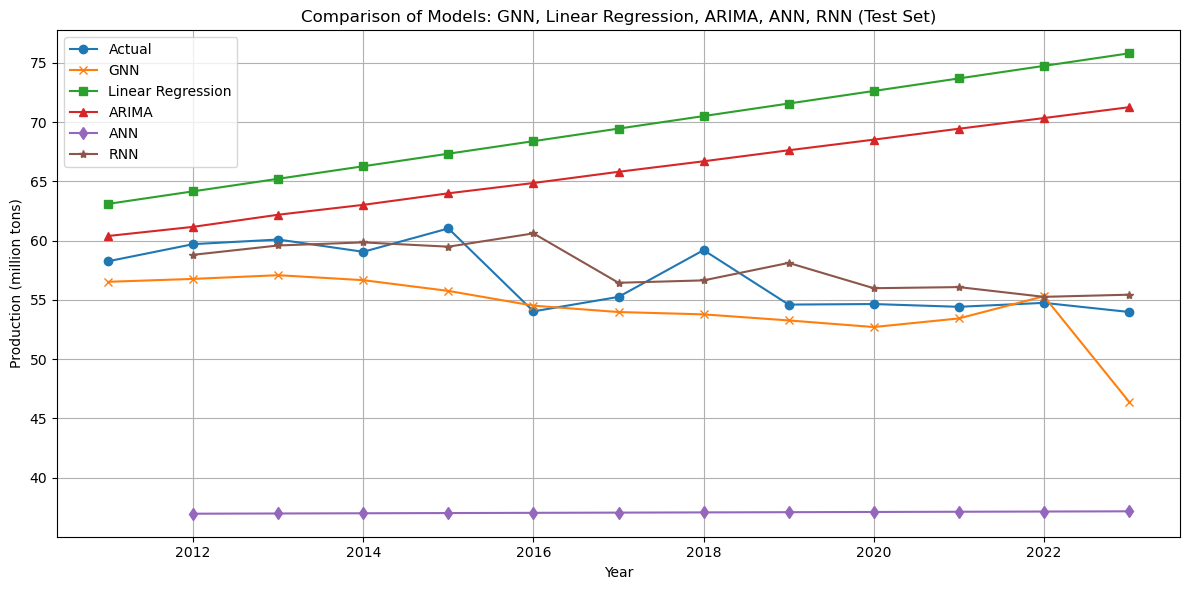

In [38]:
# Komparasi model: GNN, Linear Regression, ARIMA, ANN, dan RNN pada test set

plt.figure(figsize=(12, 6))
plt.plot(years[test_idx], test_actual / 1e6, label='Actual', marker='o')
plt.plot(years[test_idx], test_pred / 1e6, label='GNN', marker='x')
plt.plot(years[test_idx], linreg_pred / 1e6, label='Linear Regression', marker='s')
plt.plot(years[test_idx], arima_pred / 1e6, label='ARIMA', marker='^')
plt.plot(years_test, ann_pred[:len(years_test)] / 1e6, label='ANN', marker='d')
plt.plot(years_test, y_pred_rnn.flatten() / 1e6, label='RNN', marker='*')
plt.title('Comparison of Models: GNN, Linear Regression, ARIMA, ANN, RNN (Test Set)')
plt.xlabel('Year')
plt.ylabel('Production (million tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()